# 検証：疾患の創薬標的としての妥当性を Yes / No で判定する

**どの病気にも使える共通プロンプト**で、遺伝子リストの各遺伝子について
「この遺伝子を活性化または抑制することで、その病気や症状が改善する可能性があるか？」を AI に Yes / No で答えさせ、
**Yes の確率**を集めます。正解遺伝子（承認薬の標的）が上位に来るかを、ランダム遺伝子と比べて評価します。

## このノートの方針
- 外部の .py は参照しません。処理はセル内に書き、`def` は AI 役と UniProt 照会など、何度も呼ぶものだけに限ります（各 def の前に説明があります）。
- 変数は **設定セル** にまとめてあります：病名、病気の情報（箇条書き最大5個。**治したい症状と、それに関わる臓器・細胞・機能**。分子名・原因遺伝子名は書かない）、回答回数、遺伝子リストのファイル、モデルの場所。
- スコアは3通り取れます（確率読みが最も良く、読めないモデルでは評点を主スコアにします）。
  - **確率読み（logprob）**：次のトークンの確率から Yes / No を読む（guidance の `select` ＋ 制約前 top_k）。選択肢の順を入れ替えて2回読み、平均。
  - **サンプリング（sample）**：温度を付けて `N_ANSWERS` 回答えさせ、Yes の割合を取る。
  - **評点（rating）**：0〜9 で答えさせ、確率が読めれば期待値、読めなければサンプリング平均を 0〜1 に直す。何にでも Yes と言うモデルでも差が出る。
  - 統計的には、サンプリングの Yes 割合は確率読みの値のまわりでばらつく推定値です。Yes 偏りの強いモデルでは 1.0 に張り付いて順位が付かないため、主スコアには使いません。
- モデルは **`~/llm/models` の GGUF（guidance + llama.cpp）** と **Ollama** のどちらでも使えます。設定セルで一覧から選びます。
- モデルが無い環境では **モック**（擬似乱数）で動きます。その場合は出力に警告が出ます。数値に意味はありません。

## プロンプトに入れる遺伝子名
遺伝子記号だけでなく **タンパク質名** も入れます（例: `TNF (tumor necrosis factor)`）。
タンパク質名は UniProt から取得し（届かない環境ではキャッシュ → HGNC の遺伝子名の順に代用）、どこから来たかを列に残します。

### このセルがすること：準備
- 標準ライブラリと pandas / matplotlib を読み込みます。

In [1]:
import os, re, csv, math, glob, json, time, random, hashlib, urllib.request, urllib.parse
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 80)
ROOT = os.path.abspath("..")          # notebooks/ から実行する前提。1つ上がリポジトリ直下
print("ready:", ROOT)

ready: /home/user/gene_disease_prediction02


## 設定（ここだけ変えれば別の病気・別のリストで使える）

### このセルがすること：変数をまとめて宣言する
- 病名・箇条書き・遺伝子リストは前のセル（疾患の選択）で決まります。
- **`DISEASE_INFO` の書き方のルール**
  1. 「治したい症状」を主語にし、「その症状が、どの臓器・どの細胞の、どんな機能の異常と関係するか」を書く。
  2. **分子名（サイトカイン名、受容体名、神経伝達物質名など）と、原因遺伝子名は書かない。** 書くと、その分子の遺伝子が質問の答えに漏れて、AI の知識ではなくプロンプトで順位が決まってしまう。
  3. 次のセルで、箇条書きに遺伝子記号・遺伝子名が混ざっていないかを HGNC の一覧で自動点検する。
- 遺伝子リストは `symbol` 列が必須。`protein_name_uniprot` `gene_name` `uniprot_ids` `category` `label` 列があれば使います。
- `N_ANSWERS`：サンプリングで答えさせる回数。`TEMPERATURE`：その温度。`MODE`：`"logprob"` / `"sample"` / `"both"`。
- `MAX_GENES`：試しに少数で回すときの上限（None なら全部）。
- **モデルの選択**：`~/llm/models` の GGUF と、起動中の Ollama のモデルを一覧にして選びます。`BACKEND`（auto / gguf / ollama / mock）と `MODEL_SELECT`（auto / 番号 / 名前の一部）で指定。auto なら txgemma → medgemma → gemma の順で優先。どれも無ければモック。
- `USE_RATING`：Yes/No に加えて **評点**を取ります。確率が読めるモデルでは 0〜9 の各数字の確率から期待値を出します（1桁＝1トークンなので確率が読める）。確率が読めないモデル（Ollama）では `RATING_SCALE_SAMPLING`（既定 0〜100）で答えさせ、`N_ANSWERS` 回の平均を取ります。0〜9 だと 5 回とも同じ数字になって順位が付かないためです。
- `STRICT_PROMPT`：「大半の遺伝子は標的ではない。明確な根拠がなければ No」と前置きします（小型の指示調整モデルは何にでも Yes と言う癖があるため）。
- `USE_CONTROLS`：無関係な対照疾患でも同じ質問をして平均を引く「有名度の補正」。何にでも手を挙げる遺伝子を割り引きます。計算量が増えるので既定は off。
- `OLLAMA_TEMPLATE`：Ollama では会話テンプレートを自分で組み（`raw: true`）、「Answer:」をモデルの発話の先頭に置きます。こうしないとモデルが「Answer: Yes」と書き始め、Yes/No を読む位置がずれます。auto はモデル名から gemma / llama3 / chatml を推定します。

## 疾患の選択

### このセルがすること：`data/diseases.json` の登録疾患から1つ選び、病名・症状の箇条書き・遺伝子リストを読み込む
- `DISEASE_KEY` を変えるだけで切り替わります：`ra` / `scz` / `cystinuria` / `prostate_cancer` / `achondroplasia`。
- 箇条書きは「症状 → 臓器・細胞・機能」で書かれ、分子名・原因遺伝子名を含みません（テストで HGNC 記号との照合済み）。
- 遺伝子リストは `data/genes/<疾患>_set100.tsv`。RA 以外はダミーに SLC トランスポーターを多数含みます（シスチン尿症は原因遺伝子も SLC なので厳しい検証になります）。

In [2]:
DISEASE_KEY = "ra"                    # "ra" / "scz" / "cystinuria" / "prostate_cancer" / "achondroplasia"
GENE_SET = "set100"                   # "set100" / "set1000" / "known" / "candidates"

REGISTRY = json.load(open(os.path.join(ROOT, "data", "diseases.json"), encoding="utf-8"))
print("登録疾患:", {k: v["name"] for k, v in REGISTRY.items()})
D = REGISTRY[DISEASE_KEY]
DISEASE = D["name"]
DISEASE_INFO = D["info"][:5]
GENE_FILE = os.path.join(ROOT, "data", "genes", f"{D['gene_prefix']}_{GENE_SET}.tsv")
print("選択:", DISEASE, "| 遺伝子リスト:", os.path.basename(GENE_FILE))
for b in DISEASE_INFO: print("  -", b[:110] + ("…" if len(b) > 110 else ""))

登録疾患: {'ra': 'rheumatoid arthritis', 'scz': 'schizophrenia', 'cystinuria': 'cystinuria', 'prostate_cancer': 'prostate cancer', 'achondroplasia': 'achondroplasia'}
選択: rheumatoid arthritis | 遺伝子リスト: ra_set100.tsv
  - Joint pain, swelling and morning stiffness, symmetric in the small joints of hands and feet: caused by chronic…
  - Progressive joint deformity and loss of function: invasive growth of the synovial lining cells and excessive b…
  - The inflammation is sustained by the adaptive immune system: self-reactive T cells, antibody-producing B cells…
  - Fatigue, low-grade fever and anaemia: systemic effects of inflammatory mediators released by the activated imm…
  - Accelerated cardiovascular disease and interstitial lung disease: consequences of long-standing systemic infla…


In [3]:
# --- 遺伝子リスト ---
MAX_GENES = None                                   # 例: 20 で試運転

# --- 回答方法 ---
MODE = "both"                                      # "logprob" / "sample" / "both"（Yes/No の確率読み・サンプリング）
USE_RATING = True                                  # 評点も取る（logprobs が無いモデルではこれが主スコアになる）
RATING_SCALE_SAMPLING = 100                        # 確率が読めない（サンプリングの）ときの評点の目盛り。0〜9 だと5回とも同じ数字になり順位が付かないので 0〜100 にする
N_ANSWERS = 5                                      # サンプリングの回答回数
TEMPERATURE = 0.7                                  # サンプリングの温度
STRICT_PROMPT = True                               # 「大半の遺伝子は標的ではない。明確な根拠がなければ No」と前置きする（Yes 偏りの抑制）

# --- 偏りの補正（任意）：無関係な対照疾患でも同じ質問をして、その平均を引く ---
USE_CONTROLS = False                               # True にすると計算量が (1 + 対照疾患数) 倍になる
CONTROL_DISEASES = {                               # 対照疾患も「症状 → 臓器・細胞・機能」で書く（分子名なし）
    "migraine": [
        "Recurrent throbbing unilateral headache with nausea and sensitivity to light and sound: abnormal excitability of trigeminal sensory neurons and brainstem pain circuits",
        "Visual aura preceding headache: a wave of depressed neuronal activity spreading across the visual cortex",
    ],
    "type 2 diabetes mellitus": [
        "Chronic high blood glucose with thirst and fatigue: reduced insulin-independent glucose uptake by muscle and fat cells and excess glucose output by the liver",
        "Progressive loss of glucose control: exhaustion and loss of the hormone-secreting beta cells of the pancreatic islets",
    ],
}

# --- モデルの選択 ---
# BACKEND: "auto" = Ollama が起動していれば Ollama、無ければ ~/llm/models の GGUF、それも無ければモック
#          "gguf" / "ollama" / "mock" で固定もできる
BACKEND = "auto"
MODEL_DIR = os.path.expanduser("~/llm/models")            # GGUF の置き場所
OLLAMA_URL = "http://localhost:11434"                     # Ollama サーバー
OLLAMA_TEMPLATE = "auto"                                  # "auto" / "gemma" / "llama3" / "chatml" / "none"。raw モードで会話テンプレートを自分で組み、
                                                          # 「Answer:」をモデルの発話の先頭に置く（答えの位置で確率を読むため）
MODEL_SELECT = "auto"                                     # "auto" / 一覧の番号（例 2）/ 名前の一部（例 "medgemma"）
PREFER = ("txgemma", "medgemma", "gemma")                 # auto のとき、この順で名前に含むものを優先
TOP_K = 50                                                # 確率読みで記録する上位トークン数

# 使えるモデルを集める（GGUF ファイルと Ollama のモデル）
models = []
for h in sorted(glob.glob(os.path.join(MODEL_DIR, "**", "*.gguf"), recursive=True)):
    models.append({"kind": "gguf", "name": os.path.basename(h), "path": h, "size_gb": round(os.path.getsize(h) / 1e9, 2)})
try:
    with urllib.request.urlopen(OLLAMA_URL + "/api/tags", timeout=3) as r:
        for m in json.load(r).get("models", []):
            models.append({"kind": "ollama", "name": m["name"], "path": m["name"], "size_gb": round(m.get("size", 0) / 1e9, 2)})
except Exception:
    pass                                                   # Ollama が起動していない

# 選ぶ
chosen = None
if BACKEND == "mock":
    pass
elif isinstance(MODEL_SELECT, int):
    chosen = models[MODEL_SELECT]
else:
    pool = [m for m in models if BACKEND == "auto" or m["kind"] == BACKEND]
    if MODEL_SELECT != "auto":
        pool = [m for m in pool if MODEL_SELECT.lower() in m["name"].lower()]
    ranked = sorted(pool, key=lambda m: (min([i for i, p in enumerate(PREFER) if p in m["name"].lower()] or [99]),
                                         0 if m["kind"] == "ollama" else 1, m["name"]))
    chosen = ranked[0] if ranked else None
USE_LLM = chosen is not None
BACKEND_USED = chosen["kind"] if chosen else "mock"
MODEL_PATH = chosen["path"] if chosen else None            # GGUF ならファイルパス、Ollama ならモデル名

print("使えるモデル:")
for i, m in enumerate(models): print(f"  [{i}] {m['kind']:6s} {m['size_gb']:6.2f} GB  {m['name']}")
print("選択:", f"{BACKEND_USED}: {MODEL_PATH}" if USE_LLM else "モック（擬似乱数。数値に意味なし）")

# --- 出力 ---
OUT_DIR = os.path.join(ROOT, "outputs"); os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, os.path.basename(GENE_FILE).replace(".tsv", "") + "_yesno.csv")

print("disease:", DISEASE, "| info bullets:", len(DISEASE_INFO))
print("gene file:", GENE_FILE)


使えるモデル:
選択: モック（擬似乱数。数値に意味なし）
disease: rheumatoid arthritis | info bullets: 5
gene file: /home/user/gene_disease_prediction02/data/genes/ra_set100.tsv


## 共通プロンプト

### このセルがすること：どの病気でも使う質問文の雛形を決め、例を表示し、漏れを点検する
- 変数は `{disease}`（病名）、`{info}`（症状と臓器・細胞・機能の箇条書き）、`{gene}`（記号＋タンパク質名）の3つだけです。
- 「活性化または抑制することで改善する可能性があるか」を1問で聞きます。向き（活性化か抑制か）は問いません。
- 選択肢の順（Yes or No / No or Yes）は `{options}` で入れ替えます。`STRICT_PROMPT` が True なら「大半の遺伝子は標的ではない」の前置きが **Yes/No と評点の両方に** 入ります（片方だけだと2つのスコアの基準がずれます）。
- 評点用の雛形 `RATING_TEMPLATE` も定義します。確率が読めるときは 0〜9（1桁＝1トークン）、読めないときは 0〜`RATING_SCALE_SAMPLING`（既定 100）の整数で答えさせます。
- `render_prompt` / `render_rating_prompt` は `disease` と `info_list` を渡すと対照疾患用の文になります。
- 最後に、箇条書きに HGNC の遺伝子記号・遺伝子名・代表的な分子名（神経伝達物質、サイトカイン等）が含まれていないかを点検し、あれば警告します（止めはしません）。

In [4]:
STRICT_NOTE = ("Note: the vast majority of human genes are NOT plausible drug targets for any given disease. "
               "Answer Yes only if there is a clear mechanistic link between this gene's function and the disease's symptoms; otherwise answer No.\n")
PROMPT_TEMPLATE = (
    "You are an expert in drug discovery and human disease biology.\n"
    "{strict}"
    "Disease: {disease}\n"
    "Target symptoms and the organ, cell and functional abnormalities behind them:\n{info}\n"
    "Gene: {gene}\n"
    "Question: Could activating or inhibiting this gene plausibly improve {disease} or its symptoms, "
    "i.e. is it a plausible drug target for {disease}?\n"
    "{options}\n"
    "Answer:"
)
OPTIONS = {"yes_first": "Answer with Yes or No.", "no_first": "Answer with No or Yes."}

STRICT_NOTE_RATING = ("Note: the vast majority of human genes have no plausible link to any given disease and should be rated 0 or 1. "
                      "Reserve high ratings for genes with a clear mechanistic link to the listed symptoms.\n")
RATING_TEMPLATE = (
    "You are an expert in drug discovery and human disease biology.\n"
    "{strict}"
    "Disease: {disease}\n"
    "Target symptoms and the organ, cell and functional abnormalities behind them:\n{info}\n"
    "Gene: {gene}\n"
    "Question: How plausible is it that activating or inhibiting this gene would improve {disease} or its symptoms? "
    "Rate from 0 (no plausible link; true for most genes) to {scale} (established, validated drug target).\n"
    "{instruction}\n"
    "Answer:"
)

def render_prompt(gene_label, order="yes_first", disease=None, info_list=None):
    """Yes/No 用のプロンプト。disease / info_list を渡すと対照疾患用になる。"""
    info = "\n".join(f"- {b}" for b in (info_list or DISEASE_INFO))
    return PROMPT_TEMPLATE.format(strict=STRICT_NOTE if STRICT_PROMPT else "", disease=disease or DISEASE, info=info,
                                  gene=gene_label, options=OPTIONS[order])

def render_rating_prompt(gene_label, disease=None, info_list=None, scale=9):
    """評点用のプロンプト。scale=9 なら「1桁で答えよ」、それ以外は「0〜scale の整数で答えよ」。"""
    info = "\n".join(f"- {b}" for b in (info_list or DISEASE_INFO))
    instruction = "Answer with a single digit." if scale == 9 else f"Answer with a single integer between 0 and {scale}."
    return RATING_TEMPLATE.format(strict=STRICT_NOTE_RATING if STRICT_PROMPT else "", disease=disease or DISEASE, info=info,
                                  gene=gene_label, scale=scale, instruction=instruction)

print(render_prompt("TNF (tumor necrosis factor)"))
print("\n--- rating prompt, logprob mode (last 3 lines) ---\n" + "\n".join(render_rating_prompt("TNF (tumor necrosis factor)").splitlines()[-3:]))
print("\n--- rating prompt, sampling mode (last 3 lines) ---\n" + "\n".join(render_rating_prompt("TNF (tumor necrosis factor)", scale=RATING_SCALE_SAMPLING).splitlines()[-3:]))

# --- 漏れの点検：箇条書きに遺伝子記号・遺伝子名・代表的な分子名が入っていないか ---
hgnc = pd.read_csv(os.path.join(ROOT, "data", "genes", "hgnc_protein_coding.tsv"), sep="\t", dtype=str).fillna("")
symbols = set(hgnc["symbol"])
long_names = {n.lower() for n in hgnc["gene_name"] if len(n) >= 10}          # 短い遺伝子名（例 "actin"）は誤検出が多いので除く
MOLECULE_WORDS = ["dopamine", "serotonin", "glutamate", "gaba", "acetylcholine", "noradrenaline", "histamine",
                  "interleukin", "interferon", "cytokine tnf", "tumor necrosis", "insulin", "cortisol", "estrogen", "testosterone"]
leaks = []
for b in DISEASE_INFO:
    for tok in re.findall(r"\b[A-Z][A-Z0-9]{1,9}(?:-[A-Z0-9]{1,5})?\b", b):
        if tok in symbols: leaks.append((tok, "HGNC symbol", b[:60]))
    low = b.lower()
    for n in long_names:
        if n in low: leaks.append((n, "HGNC gene name", b[:60]))
    for w in MOLECULE_WORDS:
        if w in low: leaks.append((w, "molecule word", b[:60]))
if leaks:
    print("\n[警告] 箇条書きに分子名・遺伝子名が含まれています。書き換えを検討してください:")
    for l in leaks: print("  -", l)
else:
    print("\n点検: 遺伝子記号・遺伝子名・代表的な分子名は含まれていません。")

You are an expert in drug discovery and human disease biology.
Note: the vast majority of human genes are NOT plausible drug targets for any given disease. Answer Yes only if there is a clear mechanistic link between this gene's function and the disease's symptoms; otherwise answer No.
Disease: rheumatoid arthritis
Target symptoms and the organ, cell and functional abnormalities behind them:
- Joint pain, swelling and morning stiffness, symmetric in the small joints of hands and feet: caused by chronic inflammation of the synovial membrane that lines the joints
- Progressive joint deformity and loss of function: invasive growth of the synovial lining cells and excessive bone resorption by bone-degrading cells erode cartilage and bone
- The inflammation is sustained by the adaptive immune system: self-reactive T cells, antibody-producing B cells and infiltrating macrophages accumulate in the synovium
- Fatigue, low-grade fever and anaemia: systemic effects of inflammatory mediators rele


点検: 遺伝子記号・遺伝子名・代表的な分子名は含まれていません。


## 入力遺伝子

### このセルがすること：遺伝子リストを読み込む
- `symbol` 列が無ければ止まります。`category` / `label` が無ければ空欄にします（評価の一部が省略されます）。

In [5]:
genes = pd.read_csv(GENE_FILE, sep="\t", dtype=str).fillna("")
assert "symbol" in genes.columns, "symbol 列が必要です"
for col in ("protein_name_uniprot", "gene_name", "uniprot_ids", "category", "label"):
    if col not in genes.columns: genes[col] = ""
if MAX_GENES: genes = genes.head(MAX_GENES).copy()
print(len(genes), "genes")
genes[["symbol", "gene_name", "uniprot_ids", "protein_name_uniprot", "category", "label"]].head(8)

100 genes


,symbol,gene_name,uniprot_ids,protein_name_uniprot,category,label
0,PADI4,peptidyl arginine deiminase 4,Q9UM07,,candidate,0
1,CCL21,C-C motif chemokine ligand 21,O00585,,candidate,0
2,TNFRSF14,TNF receptor superfamily member 14,Q92956,,candidate,0
3,IL7R,interleukin 7 receptor,P16871,,candidate,0
4,IRF5,interferon regulatory factor 5,Q13568,,candidate,0
5,BTK,Bruton tyrosine kinase,Q06187,,candidate,0
6,CSF2,colony stimulating factor 2,P04141,,candidate,0
7,IL2RB,interleukin 2 receptor subunit beta,P14784,,candidate,0


## タンパク質名（UniProt）

### `uniprot_protein_names(accessions)` — UniProt からタンパク質名を取る
どんな def か：UniProt アクセッション（例 P01375）のリストを渡すと、推奨タンパク質名（例 "Tumor necrosis factor"）の辞書を返します。

各ステップ：
1. キャッシュ `data/genes/uniprot_names_cache.tsv` を読み、既にあるものは問い合わせません。
2. 残りを 100 件ずつ UniProt REST（`rest.uniprot.org`）に問い合わせます（形式: TSV、列: accession, protein_name）。
3. 取れた分をキャッシュに追記します。ネットワークに届かないときは例外を握りつぶして、取れた分だけ返します。

return：dict（accession → protein name）。取れなかったものは含まれません。

### このセルがすること：各遺伝子の「プロンプトに入れる名前」を決める
優先順位：① ファイルの `protein_name_uniprot` 列 → ② UniProt 照会（キャッシュ含む） → ③ HGNC の `gene_name` → ④ 記号のみ。
どれを使ったかを `name_source` 列に残します。

In [6]:
CACHE = os.path.join(ROOT, "data", "genes", "uniprot_names_cache.tsv")

def uniprot_protein_names(accessions):
    names = {}
    if os.path.exists(CACHE):                                                       # 1. キャッシュ
        for row in csv.DictReader(open(CACHE, encoding="utf-8"), delimiter="\t"):
            names[row["accession"]] = row["protein_name"]
    todo = sorted({a for a in accessions if a and a not in names})
    fetched = {}
    for i in range(0, len(todo), 100):                                             # 2. REST に 100 件ずつ
        chunk = todo[i:i + 100]
        url = "https://rest.uniprot.org/uniprotkb/search?" + urllib.parse.urlencode(
            {"query": " OR ".join(f"accession:{a}" for a in chunk), "fields": "accession,protein_name", "format": "tsv", "size": 500})
        try:
            with urllib.request.urlopen(url, timeout=60) as r:
                for line in r.read().decode().splitlines()[1:]:
                    acc, name = line.split("\t")[:2]
                    fetched[acc] = name
        except Exception as e:
            print(f"UniProt に届きません（{type(e).__name__}）。取れた分だけ使います。"); break
    if fetched:                                                                     # 3. キャッシュに追記
        new = not os.path.exists(CACHE)
        with open(CACHE, "a", encoding="utf-8", newline="") as f:
            w = csv.writer(f, delimiter="\t")
            if new: w.writerow(["accession", "protein_name"])
            for k, v in fetched.items(): w.writerow([k, v])
    names.update(fetched)
    return names

accs = [a for s in genes["uniprot_ids"] for a in s.split("|") if a]
uni = uniprot_protein_names(accs)

labels, sources = [], []
for _, g in genes.iterrows():
    first_acc = (g["uniprot_ids"].split("|") or [""])[0]
    if g["protein_name_uniprot"]:
        name, src = g["protein_name_uniprot"].split("|")[0], "file"
    elif first_acc in uni:
        name, src = uni[first_acc], "uniprot_rest"
    elif g["gene_name"]:
        name, src = g["gene_name"], "hgnc_gene_name"
    else:
        name, src = "", "symbol_only"
    labels.append(f"{g['symbol']} ({name})" if name else g["symbol"]); sources.append(src)
genes["gene_label"] = labels; genes["name_source"] = sources
print(genes["name_source"].value_counts().to_dict())
genes[["symbol", "gene_label", "name_source"]].head(8)

UniProt に届きません（URLError）。取れた分だけ使います。
{'hgnc_gene_name': 100}


,symbol,gene_label,name_source
0,PADI4,PADI4 (peptidyl arginine deiminase 4),hgnc_gene_name
1,CCL21,CCL21 (C-C motif chemokine ligand 21),hgnc_gene_name
2,TNFRSF14,TNFRSF14 (TNF receptor superfamily member 14),hgnc_gene_name
3,IL7R,IL7R (interleukin 7 receptor),hgnc_gene_name
4,IRF5,IRF5 (interferon regulatory factor 5),hgnc_gene_name
5,BTK,BTK (Bruton tyrosine kinase),hgnc_gene_name
6,CSF2,CSF2 (colony stimulating factor 2),hgnc_gene_name
7,IL2RB,IL2RB (interleukin 2 receptor subunit beta),hgnc_gene_name


## AI 役

### `option_logprob_sum(top, option)` — 綴り違いのトークンを合算する
どんな def か：上位トークンの表（`{token: log確率}`）から、選択肢と同じ語（`Yes`, ` Yes`, `yes`, `YES` など空白・大小文字違い）を全部集め、確率を合算して log で返します。
**完全一致を優先してはいけません。** 実機では本命が `'Yes'`（−0.002）なのに `' Yes'`（−12.45）を拾って順位が逆転しました。
return：float（合算した log 確率）。1つも無ければ None。

### `option_logprobs(prompt, options)` — 各選択肢の log 確率を読む
どんな def か：質問文と選択肢（`[" Yes", " No"]`）を渡し、制約をかける前の次トークン分布から各選択肢の確率を拾って log で返します（お使いの関数と同じ仕組み）。

各ステップ：1. `llm.copy() + prompt` → 2. `select(options)` で答えを限定 → 3. トレースの最初の生成トークンの `top_k` を候補に → 4. 選択肢に一致する token（空白違いも可）の prob を探す → 5. 無ければ top_k の最小確率で代用し `missing` に記録。

return：dict（`{"Yes": log p, "No": log p}`）。

### `yes_probability(gene_label)` — 確率読みで Yes 確率を出す
各ステップ：1. 選択肢の順 2通りでプロンプトを作る → 2. それぞれ `option_logprobs` → `pY/(pY+pN)` → 3. 2つの平均。
return：float。

### `sample_yes_fraction(gene_label, n, temperature)` — n 回答えさせて Yes の割合を出す
各ステップ：1. 回ごとに選択肢の順を交互に変える → 2. `gen(max_tokens=3, temperature)` で答えを生成 → 3. 先頭の語が Yes / No かを判定（どちらでもなければ「無効」に数える） → 4. Yes の数 ÷ 有効回答数。
return：(float, 有効回答数, Yes の数)。

### `rating_score(gene_label)` — 0〜9 の評点を 0〜1 のスコアにする
どんな def か：確率が読めるモデルでは 0〜9 で「1桁で答えよ」と聞き、**各数字の確率から期待値**（Σ d·p_d ÷ Σ p_d ÷ 9）を返します。読めないモデルでは 0〜`RATING_SCALE_SAMPLING`（既定 100）の整数で答えさせ、**n 回の平均 ÷ 目盛り** を返します。Yes/No の多数決より解像度が高く、何にでも Yes と言うモデルでも差が出ます。
return：float（0〜1）。

### `wrap_for_ollama(prompt)` — 会話テンプレートを自分で組み、「Answer:」をモデル側の先頭に置く
どんな def か：Ollama にテンプレートを任せると、プロンプト末尾の「Answer:」がユーザー側の文に入り、モデルは自分の発話を「Answer: Yes」から書き始めます。すると Yes/No を読む位置が答えの位置になりません（実機で最頻トークンが 'Answer' になっていました）。この def は「Answer:」を切り離して、モデル側の発話の先頭に付け直した全文を返し、`raw: true` で送ります。guidance の `select` と同じ位置関係です。
return：str（テンプレート込みの全文）。

### `ollama_generate(prompt, temperature, max_tokens)` / `ollama_top_logprobs(prompt, k)` — Ollama 用の下請け
どんな def か：起動中の Ollama サーバー（`http://localhost:11434`）に HTTP で問い合わせます。前者は `/api/generate` で文章を生成して str を返します。後者は OpenAI 互換の `/v1/completions` に `logprobs` を要求し、先頭1トークンの上位 k 個の `{token: log確率}` を返します。`/api/generate`（`logprobs: true, top_logprobs ≤ 20`）→ `/v1/completions`（`logprobs` は個数）の順に試し、取れた方を以後使います。上位件数は Ollama の上限 20 に丸めます。どちらも非対応なら None を返し、読込時に「非対応」と表示します。その場合 `yes_probability` は None になり、主スコアは評点になります。

### このセルがすること：上の def を定義する（GGUF なら guidance で読み込み、Ollama ならその下請けを使い、無ければモック）
- モックは遺伝子名のハッシュから擬似乱数を作るだけです。**数値に意味はありません。**

In [7]:
missing = []
LOGPROBS_OK = False                 # 確率（logprobs）が読めるか。False なら評点（rating）を主スコアにする
OLLAMA_LP_ENDPOINT = None           # Ollama で logprobs が取れたエンドポイント

if BACKEND_USED == "gguf":
    from guidance import select, gen
    from guidance.models import LlamaCpp
    llm = LlamaCpp(MODEL_PATH, echo=True, top_k=TOP_K, n_ctx=1024, n_gpu_layers=-1, verbose=False)
    LOGPROBS_OK = True
elif BACKEND_USED == "ollama":
    print("Ollama を使います:", MODEL_PATH)
else:
    print("警告: モデルが見つからないため、モック（擬似乱数）で動きます。数値に意味はありません。")
    LOGPROBS_OK = True

# ---- Ollama 用の下請け（HTTP で localhost の Ollama に聞く） ----
LOGPROB_CONVENTION = None          # 返ってきた値の規約: "logprob"(≤0) / "prob"(0〜1) / "neg_logprob"(正の値) を自動判定
LAST_RAW = {}                      # 診断用: 最後の生の応答を保存
FLIP_SIGN = False                  # 読込時の検証で「向きが逆」と判定されたら True にして符号を反転する
GREEDY_CHECK = {"agree": 0, "disagree": 0}   # 温度0の生成文字と p_yes の向きが一致した／しなかった回数
LAST_GREEDY = None                 # 直近の確率読みで、温度0で生成された最初の語（yes / no / その他）

def to_logprobs(top):
    """Ollama が返した {token: 値} を対数確率に揃える。値の規約を自動判定して LOGPROB_CONVENTION に記録する。"""
    global LOGPROB_CONVENTION
    vals = list(top.values())
    if not vals: return top
    if all(v <= 0 for v in vals):
        conv = "logprob"
        out = dict(top)
    elif all(0 <= v <= 1 for v in vals) and sum(vals) <= 1.0001:
        conv = "prob"                                          # 確率そのもの → log にする
        out = {t: math.log(max(v, 1e-12)) for t, v in top.items()}
    else:
        conv = "neg_logprob"                                   # −log p（正の値）→ 符号を反転
        out = {t: -v for t, v in top.items()}
    if LOGPROB_CONVENTION is None:
        LOGPROB_CONVENTION = conv
        print(f"logprob の規約: {conv}（例 {dict(list(top.items())[:3])}）")
    elif conv != LOGPROB_CONVENTION:
        print(f"[警告] logprob の規約が変わりました: {LOGPROB_CONVENTION} → {conv}")
    if FLIP_SIGN:
        out = {t: -v for t, v in out.items()}
    return out

TEMPLATES = {
    "gemma":  "<start_of_turn>user\n{body}<end_of_turn>\n<start_of_turn>model\n",
    "llama3": "<|begin_of_text|><|start_header_id|>user<|end_header_id|>\n\n{body}<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n",
    "chatml": "<|im_start|>user\n{body}<|im_end|>\n<|im_start|>assistant\n",
    "qwen3":  "<|im_start|>user\n{body}<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n",   # 思考ブロックを空にして答えの位置に来させる
    "mistral": "[INST] {body} [/INST] ",
    "none":   "{body}\n",
}
def detect_template(name):
    n = (name or "").lower()
    if "gemma" in n: return "gemma"                      # txgemma / medgemma / gemma3
    if "llama" in n: return "llama3"
    if "qwen3" in n: return "qwen3"                      # 思考モデル: 空の think ブロックを置く
    if "mistral" in n: return "mistral"                  # biomistral など
    if any(k in n for k in ("qwen", "deepseek", "yi", "phi")): return "chatml"
    return "none"
OLLAMA_TPL = detect_template(MODEL_PATH) if OLLAMA_TEMPLATE == "auto" else OLLAMA_TEMPLATE

def wrap_for_ollama(prompt):
    """プロンプト末尾の「Answer:」を切り離し、会話テンプレートのモデル側の先頭に置く。返り値は raw モード用の全文。"""
    body, prefix = prompt, ""
    if prompt.rstrip().endswith("Answer:"):
        body = prompt.rstrip()[: -len("Answer:")].rstrip()
        prefix = "Answer:"
    return TEMPLATES[OLLAMA_TPL].format(body=body) + prefix

def ollama_post(path, body):
    req = urllib.request.Request(OLLAMA_URL + path, data=json.dumps(body).encode(), headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=300) as r:
        return json.load(r)

def ollama_generate(prompt, temperature=0.0, max_tokens=64):
    """Ollama の /api/generate に1回問い合わせ、生成された文章を返す（raw モード：テンプレートは自分で組む）。"""
    return ollama_post("/api/generate", {"model": MODEL_PATH, "prompt": wrap_for_ollama(prompt), "raw": True, "stream": False,
                                         "options": {"temperature": temperature, "num_predict": max_tokens}})["response"]

def ollama_top_logprobs(prompt, k=20):
    """先頭1トークンの上位 k 個の {token: log確率} を返す。非対応なら None。

    Ollama の仕様（api/types.go）: /api/generate と /api/chat は logprobs: true, top_logprobs: 0〜20（20 が上限）。
    OpenAI 互換の /v1/completions では logprobs は「個数（整数）」。応答は logprobs.content[0].top_logprobs。
    /api/generate → /v1/completions の順に試し、取れた方を以後使う。"""
    global OLLAMA_LP_ENDPOINT
    k = max(1, min(int(k), 20))                                  # Ollama の上限は 20
    tries = [OLLAMA_LP_ENDPOINT] if OLLAMA_LP_ENDPOINT else ["/api/generate", "/v1/completions"]
    for ep in tries:
        try:
            if ep == "/api/generate":
                out = ollama_post(ep, {"model": MODEL_PATH, "prompt": wrap_for_ollama(prompt), "raw": True, "stream": False,
                                       "logprobs": True, "top_logprobs": k, "options": {"temperature": 0, "num_predict": 1}})
                lps = out.get("logprobs") or []
                LAST_RAW.update({"endpoint": ep, "response": out.get("response"), "logprobs0": lps[0] if lps else None, "n_positions": len(lps)})
                top = {t["token"]: t["logprob"] for t in (lps[0].get("top_logprobs", []) if lps else [])}
                if lps and not top:
                    top = {lps[0]["token"]: lps[0]["logprob"]}
            else:
                ch = ollama_post(ep, {"model": MODEL_PATH, "prompt": wrap_for_ollama(prompt), "max_tokens": 1, "temperature": 0,
                                      "logprobs": k})["choices"][0]              # completions では logprobs は個数（テンプレートは自前）
                lp = ch.get("logprobs") or {}
                if lp.get("content"):
                    top = {t["token"]: t["logprob"] for t in lp["content"][0].get("top_logprobs", [])}
                elif lp.get("top_logprobs"):
                    top = dict(lp["top_logprobs"][0])
                else:
                    top = {}
            if top:
                OLLAMA_LP_ENDPOINT = ep
                return to_logprobs(top)
        except Exception:
            continue
    return None
if BACKEND_USED == "ollama":                                         # 読込時に対応を確かめて表示する
    probe = ollama_top_logprobs("Answer with Yes or No.\nIs the sky blue?\nAnswer:", 5)
    LOGPROBS_OK = probe is not None
    print("logprobs:", f"対応（{OLLAMA_LP_ENDPOINT}） 例 {dict(list(probe.items())[:3])}" if LOGPROBS_OK
          else "非対応 → Yes/No の確率は読めません。主スコアは評点のサンプリング平均になります。")
    print("会話テンプレート:", OLLAMA_TPL, "（raw モード。「Answer:」をモデル側の先頭に置く）")
    if LOGPROBS_OK:
        top1 = max(probe, key=probe.get).strip().lower()
        if top1 not in ("yes", "no"):
            print(f"[警告] 答えの位置の最頻トークンが {top1!r} です。テンプレートが合っていない可能性があります（OLLAMA_TEMPLATE を変えてください）。")

# ---- 選択肢の log 確率（Yes/No でも 0〜9 の数字でも使う） ----
def option_logprob_sum(top, option):
    """top（{token: log確率}）から、選択肢と綴り違いのトークン（'Yes', ' Yes', 'yes', 'YES' …）を全部集めて確率を合算し、
    log で返す。1つも無ければ None。※完全一致を優先すると末端の綴り（' Yes' −12）を拾って逆転する（実機で確認）。"""
    key = option.strip().lower()
    vals = [v for t, v in top.items() if t.strip().lower() == key]
    if not vals: return None
    m = max(vals)
    return m + math.log(sum(math.exp(v - m) for v in vals))

def option_logprobs(prompt, options):
    if not USE_LLM:                                                                 # モック
        h = int(hashlib.md5(prompt.encode()).hexdigest(), 16) % 1000 / 1000
        if set(o.strip() for o in options) == {"Yes", "No"}:
            return {"Yes": math.log(max(h, 1e-6)), "No": math.log(max(1 - h, 1e-6))}
        return {o.strip(): math.log(max(1e-6, math.exp(-abs(int(o) - 9 * h)))) for o in options}
    if BACKEND_USED == "ollama":                                                    # Ollama
        top = ollama_top_logprobs(prompt, TOP_K)
        if top is None:
            return None                                                             # 呼び出し側でサンプリングに切り替える
        floor = min([math.exp(v) for v in top.values()] or [1e-6])
        result = {}
        for option in options:
            v = option_logprob_sum(top, option)                                     # 綴り違いを合算
            if v is not None: result[option.strip()] = v
            else: missing.append({"prompt": prompt[-80:], "option": option}); result[option.strip()] = math.log(floor)
        # 温度0で実際に生成された語（LAST_RAW["response"]）と、計算した向きが一致するかを数える
        global LAST_GREEDY
        m = re.match(r"\s*\W*([A-Za-z]+)", LAST_RAW.get("response") or "")
        LAST_GREEDY = m.group(1).lower() if m else None
        if set(o.strip() for o in options) == {"Yes", "No"} and LAST_GREEDY in ("yes", "no"):
            computed_yes = result["Yes"] > result["No"]
            GREEDY_CHECK["agree" if computed_yes == (LAST_GREEDY == "yes") else "disagree"] += 1
        return result
    state = llm.copy() + prompt                                                     # 1. GGUF (guidance)
    state += select(options, name="answer")                                         # 2.
    generated = [o for node in state._trace_nodes for o in node.output
                 if type(o).__name__ == "TokenOutput" and not o.is_input]
    candidates = generated[0].top_k or []                                           # 3.
    floor = min((c.prob for c in candidates if c.prob and c.prob > 0), default=1e-6)
    result = {}
    top = {}
    for c in candidates:                                                            # 4. 綴り違いを合算するため {token: logprob} にまとめる
        if c.prob and c.prob > 0:
            top[c.token] = math.log(c.prob) if c.token not in top else max(top[c.token], math.log(c.prob))
    for option in options:
        v = option_logprob_sum(top, option)
        if v is not None:
            result[option.strip()] = v
        else:                                                                       # 5.
            missing.append({"prompt": prompt[-80:], "option": option}); result[option.strip()] = math.log(floor)
    return result

def yes_probability(gene_label, disease=None, info_list=None):
    """確率読み。選択肢の順 2通りの平均。logprobs が読めなければ None。"""
    ps = []
    for order in ("yes_first", "no_first"):                                          # 1.
        lp = option_logprobs(render_prompt(gene_label, order, disease, info_list), [" Yes", " No"])   # 2.
        if lp is None: return None
        ps.append(math.exp(lp["Yes"]) / (math.exp(lp["Yes"]) + math.exp(lp["No"])))
    return sum(ps) / len(ps)                                                         # 3.

def sample_yes_fraction(gene_label, n=N_ANSWERS, temperature=TEMPERATURE):
    yes = valid = 0
    for i in range(n):
        order = "yes_first" if i % 2 == 0 else "no_first"                           # 1.
        prompt = render_prompt(gene_label, order)
        if BACKEND_USED == "gguf":
            state = llm.copy() + prompt + " " + gen(name="a", max_tokens=3, temperature=temperature)   # 2. GGUF
            text = state["a"]
        elif BACKEND_USED == "ollama":
            text = ollama_generate(prompt, temperature=temperature, max_tokens=3)                        # 2. Ollama
        else:
            p = math.exp(option_logprobs(prompt, [" Yes", " No"])["Yes"])
            a, b = p ** (1 / temperature), (1 - p) ** (1 / temperature)              # モックでも温度で鋭くする（本物と同じ関係）
            text = "Yes" if random.Random(prompt + str(i)).random() < a / (a + b) else "No"
        word = re.match(r"\s*([A-Za-z]+)", text or "")                                 # 3.
        word = word.group(1).lower() if word else ""
        if word.startswith("yes"): yes += 1; valid += 1
        elif word.startswith("no"): valid += 1
    return (yes / valid if valid else float("nan")), valid, yes                      # 4. (割合, 有効回答数, Yes の数)

DIGITS = [str(d) for d in range(10)]
def rating_score(gene_label, n=N_ANSWERS, temperature=TEMPERATURE, disease=None, info_list=None):
    """評点を 0〜1 に直して返す。確率が読めれば 0〜9 の期待値、読めなければ 0〜RATING_SCALE_SAMPLING を n 回サンプリングした平均。"""
    if LOGPROBS_OK:                                                                  # 期待値 Σ d·p_d / Σ p_d（1桁＝1トークン）
        prompt = render_rating_prompt(gene_label, disease, info_list, scale=9)
        lp = option_logprobs(prompt, [" " + d for d in DIGITS])
        if lp is not None:
            ps = {int(d): math.exp(lp[d]) for d in DIGITS}
            z = sum(ps.values())
            return sum(d * pd_ for d, pd_ in ps.items()) / z / 9.0
    scale = RATING_SCALE_SAMPLING
    prompt = render_rating_prompt(gene_label, disease, info_list, scale=scale)
    vals = []
    for i in range(n):                                                               # サンプリング（整数を読む）
        text = (ollama_generate(prompt, temperature=temperature, max_tokens=4) if BACKEND_USED == "ollama"
                else (llm.copy() + prompt + " " + gen(name="a", max_tokens=4, temperature=temperature))["a"])
        m = re.search(r"\d{1,3}", text or "")
        if m and int(m.group(0)) <= scale: vals.append(int(m.group(0)))
    return (sum(vals) / len(vals) / scale) if vals else float("nan")

# ---- 向きの検証（Ollama）：答えが自明な2問で、確率読みと温度0の生成文字が同じ向きかを確かめる ----
if BACKEND_USED == "ollama" and LOGPROBS_OK:
    anchors = [("Answer with Yes or No.\nIs the sky blue on a clear day?\nAnswer:", True),
               ("Answer with Yes or No.\nIs fire cold?\nAnswer:", False)]
    wrong = 0
    for q, expect_yes in anchors:
        lp = option_logprobs(q, [" Yes", " No"])
        got_yes = lp["Yes"] > lp["No"]
        greedy = LAST_GREEDY
        print(f"  検証: {q.splitlines()[1]:35s} 期待={'Yes' if expect_yes else 'No':3s} 温度0の生成={greedy} 確率読み={'Yes' if got_yes else 'No'}")
        wrong += (got_yes != expect_yes)
    if wrong == 2:
        FLIP_SIGN = True
        print("[警告] 確率読みの向きが2問とも逆でした。符号を反転して使います（FLIP_SIGN=True）。診断セルの出力を確認してください。")
        GREEDY_CHECK["agree"] = GREEDY_CHECK["disagree"] = 0
    elif wrong == 1:
        print("[警告] 確率読みの向きが1問で逆でした。診断セルの出力を確認してください。")
    else:
        print("  向きの検証: 問題なし")

print("test TNF :", yes_probability("TNF (tumor necrosis factor)"), rating_score("TNF (tumor necrosis factor)"))

警告: モデルが見つからないため、モック（擬似乱数）で動きます。数値に意味はありません。
test TNF : 0.3115 0.2236691554731206


## 診断：Ollama の生の応答を見る（p_yes の向きがおかしいときに使う）

### このセルがすること：既知遺伝子とランダム遺伝子で、確率読みとサンプリングの生データを並べる
- `/api/generate` に logprobs を要求したときの **生成文字**、`logprobs[0]` の **token と値の上位5件**、そこから計算した p_yes。
- 同じプロンプトを温度 0.7 でサンプリングした答え 3 回。
- 期待される整合: 生成文字が Yes なら top の先頭も Yes 系で値が 0 に近く、サンプリングも Yes が多い。**ここが食い違えば、値の規約かトークンの照合の問題**です。この出力を貼ってもらえれば原因を特定できます。

In [8]:
if BACKEND_USED == "ollama":
    for gl in ["TNF (tumor necrosis factor)", "OR8U8 (olfactory receptor family 8 subfamily U member 8)"]:
        for order in ("yes_first", "no_first"):
            prompt = render_prompt(gl, order)
            LAST_RAW.clear()
            top = ollama_top_logprobs(prompt, TOP_K)
            lp = option_logprobs(prompt, [" Yes", " No"])
            p = None if lp is None else math.exp(lp["Yes"]) / (math.exp(lp["Yes"]) + math.exp(lp["No"]))
            samples = [ollama_generate(prompt, temperature=TEMPERATURE, max_tokens=3).strip() for _ in range(3)]
            print(f"=== {gl.split(' ')[0]} / {order} ===")
            print("  生成文字(温度0, 1トークン):", repr(LAST_RAW.get("response")), "| 位置数:", LAST_RAW.get("n_positions"))
            lp0 = LAST_RAW.get("logprobs0") or {}
            print("  選ばれたトークン:", repr(lp0.get("token")), lp0.get("logprob"))
            print("  top5 (生の値):", [(t["token"], round(t["logprob"], 3)) for t in (lp0.get("top_logprobs") or [])[:5]])
            print("  規約判定:", LOGPROB_CONVENTION, "| Yes/No の対数確率:", None if lp is None else {k: round(v, 3) for k, v in lp.items()}, "| p_yes:", None if p is None else round(p, 3))
            print("  サンプリング3回(温度0.7):", samples)
else:
    print("Ollama 以外ではこの診断は不要です。")

Ollama 以外ではこの診断は不要です。


## 較正チェック（本番の前に必ず見る）

### このセルがすること：明らかに違う3種類の遺伝子で、スコアに差が付くかを確かめる
- 嗅覚受容体（どの病気の標的でもない）、無関係なランダム遺伝子、そして確立した標的（ここでは記号を伏せず TNF）を使います。
- 差（最大 − 最小）が 0.1 未満なら、そのモデルと聞き方では順位が付きません。警告を出し、対処（確率が読める GGUF を使う、評点を主スコアにする、`STRICT_PROMPT` を有効にする）を示します。

In [9]:
CAL_GENES = ["OR8U8 (olfactory receptor family 8 subfamily U member 8)",
             "KCNE4 (potassium voltage-gated channel subfamily E regulatory subunit 4)",
             "TNF (tumor necrosis factor)"]
rows = []
for gl in CAL_GENES:
    p = yes_probability(gl)
    r = rating_score(gl)
    fr, nv, ny = sample_yes_fraction(gl, n=3)
    rows.append({"gene": gl.split(" ")[0], "p_yes": None if p is None else round(p, 3), "rating": round(r, 3), "yes/valid (3 asks)": f"{ny}/{nv}", "yes_fraction": fr})
cal = pd.DataFrame(rows); display(cal)
SCORE_COL = "p_yes" if LOGPROBS_OK else "rating"
spread = cal[SCORE_COL].max() - cal[SCORE_COL].min()
print(f"主スコア: {SCORE_COL} | 3遺伝子の差: {spread:.3f}")
if spread < 0.1:
    print("[警告] スコアがほとんど同じです。このモデル・聞き方では順位が付きません。対処: (1) 確率が読める GGUF を使う "
          "(2) 評点 rating を主スコアにする (3) STRICT_PROMPT = True にする (4) より大きいモデルを使う")
elif not LOGPROBS_OK:
    print(f"注意: 確率が読めないため 0〜{RATING_SCALE_SAMPLING} 評点のサンプリング平均（{N_ANSWERS} 回, 温度 {TEMPERATURE}）を使います。N_ANSWERS を 10 以上、TEMPERATURE を 1.0 にすると差が出やすくなります。")

,gene,p_yes,rating,yes/valid (3 asks),yes_fraction
0,OR8U8,0.380,0.339,2/3,0.666667
1,KCNE4,0.395,0.133,2/3,0.666667
2,TNF,0.311,0.224,0/3,0.000000


主スコア: p_yes | 3遺伝子の差: 0.084
[警告] スコアがほとんど同じです。このモデル・聞き方では順位が付きません。対処: (1) 確率が読める GGUF を使う (2) 評点 rating を主スコアにする (3) STRICT_PROMPT = True にする (4) より大きいモデルを使う


## 実行

### このセルがすること：全遺伝子についてスコアを集め、CSV に保存する
- 取るもの：`p_yes`（確率読み。読めるモデルのみ）、`rating`（0〜9 評点を 0〜1 に）、`n_yes` / `n_valid`（サンプリングで Yes と答えた回数 / 有効回答数）と `yes_fraction`（その割合）。
- **主スコア `score`** は、確率が読めるなら `p_yes`、読めなければ `rating`（較正チェックの `SCORE_COL`）。
- `USE_CONTROLS` が True なら対照疾患でも同じ質問をし、`score_adj = score − 対照の平均` を出します。
- 1遺伝子ごとに CSV へ追記するので、途中で止めても結果は残ります。再実行時は同じモデル・同じ列構成なら済んだ遺伝子を飛ばします。
- 列構成やモデルが違う古い CSV があれば `*.old_<日時>.csv` に退避して新規に始めます（列数の混在で読めなくなるのを防ぐため）。プロンプトや温度だけを変えたときは、手で CSV を消してください。
- Ollama では、温度 0 で実際に生成された語を `greedy` 列に残し、p_yes の向きとの一致率を最後に表示します。

In [10]:
cols = ["symbol", "gene_label", "name_source", "category", "label", "p_yes", "greedy", "rating", "n_yes", "n_valid", "yes_fraction",
        "p_yes_ctrl", "rating_ctrl", "score", "score_adj", "score_col", "n_answers", "mode", "model", "disease"]
done = set()
if os.path.exists(OUT_CSV):
    with open(OUT_CSV, encoding="utf-8") as f:
        header = f.readline().strip().split(",")
    model_tag = f"{BACKEND_USED}:{os.path.basename(str(MODEL_PATH))}" if USE_LLM else "MOCK"
    prev = pd.read_csv(OUT_CSV, dtype=str, on_bad_lines="skip") if header == cols else None
    same_model = prev is not None and "model" in prev.columns and (prev["model"] == model_tag).all()
    if header != cols or not same_model:
        # 列構成またはモデルが違う古い結果 → 追記せず退避して新規に始める（列数の混在で読めなくなるのを防ぐ）
        old = OUT_CSV.replace(".csv", f".old_{time.strftime('%Y%m%d_%H%M%S')}.csv")
        os.rename(OUT_CSV, old)
        print("既存の CSV は列構成またはモデルが違うため退避しました:", os.path.basename(old))
    else:
        done = set(prev["symbol"])
        print(f"再開: 済み {len(done)} 件をスキップします")
new_file = not os.path.exists(OUT_CSV)
t0 = time.time()
def fmt(x): return "" if x is None or x == "" or (isinstance(x, float) and math.isnan(x)) else round(x, 4)
with open(OUT_CSV, "a", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    if new_file: w.writerow(cols)
    for i, g in genes.iterrows():
        if g["symbol"] in done: continue
        gl = g["gene_label"]
        p = yes_probability(gl) if MODE in ("logprob", "both") and LOGPROBS_OK else None
        greedy = LAST_GREEDY if BACKEND_USED == "ollama" else ""              # 温度0で生成された最初の語（最後の順序のもの）
        r = rating_score(gl) if USE_RATING else None
        fr, nv, ny = sample_yes_fraction(gl) if MODE in ("sample", "both") else (None, "", "")
        p_ctrl = r_ctrl = None
        if USE_CONTROLS and CONTROL_DISEASES:                                       # 対照疾患で同じ質問 → 平均
            pc = [yes_probability(gl, d, b) for d, b in CONTROL_DISEASES.items()] if p is not None else []
            rc = [rating_score(gl, disease=d, info_list=b) for d, b in CONTROL_DISEASES.items()] if r is not None else []
            p_ctrl = sum(pc) / len(pc) if pc and None not in pc else None
            r_ctrl = sum(rc) / len(rc) if rc else None
        score = p if SCORE_COL == "p_yes" else r
        ctrl = p_ctrl if SCORE_COL == "p_yes" else r_ctrl
        score_adj = (score - ctrl) if (score is not None and ctrl is not None) else None
        w.writerow([g["symbol"], gl, g["name_source"], g["category"], g["label"], fmt(p), greedy, fmt(r), ny, nv, fmt(fr),
                    fmt(p_ctrl), fmt(r_ctrl), fmt(score), fmt(score_adj), SCORE_COL, N_ANSWERS, MODE,
                    f"{BACKEND_USED}:{os.path.basename(str(MODEL_PATH))}" if USE_LLM else "MOCK", DISEASE]); f.flush()
        print(f"{i+1:4d}/{len(genes)} {g['symbol']:10s} {g['category']:9s} p_yes={fmt(p)} greedy={greedy} rating={fmt(r)} yes={ny}/{nv}"
              + (f" adj={fmt(score_adj)}" if score_adj is not None else ""))
if BACKEND_USED == "ollama" and sum(GREEDY_CHECK.values()):
    tot = sum(GREEDY_CHECK.values())
    print(f"温度0の生成文字と p_yes の向きの一致: {GREEDY_CHECK['agree']}/{tot}  （不一致が多ければ確率の読み取りが壊れています。診断セルへ）")
print(f"elapsed {time.time()-t0:.0f}s | score column: {SCORE_COL}{' (adjusted by controls)' if USE_CONTROLS else ''} | missing options: {len(missing)} | wrote {OUT_CSV}")

再開: 済み 100 件をスキップします
elapsed 0s | score column: p_yes | missing options: 0 | wrote /home/user/gene_disease_prediction02/outputs/ra_set100_yesno.csv


## 結果

### このセルがすること：結果を読み込み、分類ごとの分布を表と図にする
- 順位には `score_adj`（対照補正あり）があればそれを、無ければ `score` を使います。
- 図は分類（known / candidate / random）ごとのスコアの分布です。正解が右に寄っていれば、質問は「効いて」います。
- サンプリングで **Yes と答えた回数**を、遺伝子ごと（`yes/valid` 列）と分類ごと（回数の合計、Yes 率、全回答 Yes の遺伝子数）に示します。

順位に使う列: score | 元の列: p_yes
警告: モックの数値です。


p_yes              rating              yes_fraction               score             
            mean median count   mean median count         mean median count   mean median count
category                                                                                       
candidate  0.512  0.527    71  0.493  0.492    71        0.518    0.6    71  0.512  0.527    71
known      0.542  0.533    15  0.501  0.403    15        0.573    0.6    15  0.542  0.533    15
random     0.531  0.556    14  0.549  0.533    14        0.586    0.6    14  0.531  0.556    14

サンプリングで Yes と答えた回数（分類ごと）。all_yes_genes = 全回答が Yes だった遺伝子数（多いほど飽和）


,genes,yes_answers,valid_answers,all_yes_genes,yes_rate
category,,,,,
candidate,71,184,355,8,0.518
known,15,43,75,2,0.573
random,14,41,70,1,0.586


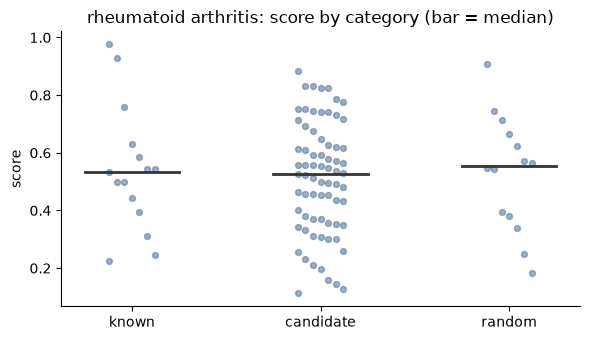

,symbol,gene_label,category,score,p_yes,rating,yes/valid
0,JAK3,JAK3 (Janus kinase 3),known,0.9780,0.9780,0.2113,5/5
1,PTGS2,PTGS2 (prostaglandin-endoperoxide synthase 2),known,0.9300,0.9300,0.3590,5/5
2,GGTLC3,GGTLC3 (gamma-glutamyltransferase light chain family member 3),random,0.9075,0.9075,0.8445,5/5
3,CD58,CD58 (CD58 molecule),candidate,0.8850,0.8850,0.6530,5/5
4,CSF2RA,CSF2RA (colony stimulating factor 2 receptor subunit alpha),candidate,0.8325,0.8325,0.4302,4/5
5,IL2RB,IL2RB (interleukin 2 receptor subunit beta),candidate,0.8315,0.8315,0.6999,5/5
6,CD247,CD247 (CD247 molecule),candidate,0.8260,0.8260,0.1529,4/5
7,CCL21,CCL21 (C-C motif chemokine ligand 21),candidate,0.8240,0.8240,0.8840,5/5
8,FCRL3,FCRL3 (Fc receptor like 3),candidate,0.7880,0.7880,0.5618,4/5
9,TNFRSF14,TNFRSF14 (TNF receptor superfamily member 14),candidate,0.7760,0.7760,0.6512,4/5


In [11]:
res = pd.read_csv(OUT_CSV)
res = res[res["disease"] == DISEASE].drop_duplicates("symbol", keep="last")
score_col = "score_adj" if ("score_adj" in res.columns and res["score_adj"].notna().any()) else "score"
res = res.sort_values(score_col, ascending=False).reset_index(drop=True)
print("順位に使う列:", score_col, "| 元の列:", res["score_col"].iloc[0] if "score_col" in res.columns else "?")
if USE_LLM is False: print("警告: モックの数値です。")
display(res.groupby("category")[[c for c in ("p_yes", "rating", "yes_fraction", "score", "score_adj") if c in res.columns and res[c].notna().any()]].agg(["mean", "median", "count"]).round(3))
if "n_yes" in res.columns and res["n_yes"].notna().any():
    res["yes/valid"] = res["n_yes"].astype("Int64").astype(str) + "/" + res["n_valid"].astype("Int64").astype(str)
    ycount = res.groupby("category").agg(genes=("symbol", "count"), yes_answers=("n_yes", "sum"), valid_answers=("n_valid", "sum"),
                                         all_yes_genes=("n_yes", lambda x: int((x == res.loc[x.index, "n_valid"]).sum())))
    ycount["yes_rate"] = (ycount["yes_answers"] / ycount["valid_answers"]).round(3)
    print("サンプリングで Yes と答えた回数（分類ごと）。all_yes_genes = 全回答が Yes だった遺伝子数（多いほど飽和）")
    display(ycount)

fig, ax = plt.subplots(figsize=(6, 3.5))
cats = [c for c in ("known", "candidate", "random") if c in set(res["category"])]
for k, cat in enumerate(cats):
    v = res.loc[res["category"] == cat, score_col].dropna()
    ax.scatter([k + (random.Random(cat).random() - 0.5) * 0.3 for _ in v] if False else [k] * len(v) + (pd.Series(range(len(v))) % 7 - 3) * 0.04, v, s=18, color="#5b7a9d", alpha=0.6)
    ax.plot([k - 0.25, k + 0.25], [v.median()] * 2, color="#333", linewidth=2)
ax.set_xticks(range(len(cats))); ax.set_xticklabels(cats); ax.set_ylabel(score_col)
ax.set_title(f"{DISEASE}: {score_col} by category (bar = median)")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
res[["symbol", "gene_label", "category", score_col] + [c for c in ("p_yes", "rating", "yes/valid") if c in res.columns and res[c].notna().any()]].head(20)

## 評価

### このセルがすること：正解遺伝子が上位に来るかを数字にする
1. **上位k中の正解数**（k = 10, 20）と、でたらめに選んだ場合の期待値（k × 正解の割合）。
2. **AUC**：正解 vs それ以外で、正解の方が高い確率を持つ割合（Mann-Whitney の U から計算）。0.5 がでたらめ、1.0 が完全。
3. **可能性 vs ランダムの AUC**：直接の報告が無い遺伝子をランダムより上に置けているか。

In [12]:
def auc(pos, neg):
    """AUC = P(正例のスコア > 負例のスコア)（同点は 0.5）。pos, neg はスコアのリスト。"""
    pos, neg = list(pos), list(neg)
    if not pos or not neg: return float("nan")
    wins = sum(1.0 if p > n else 0.5 if p == n else 0.0 for p in pos for n in neg)
    return wins / (len(pos) * len(neg))

if "label" in res.columns and res["label"].notna().any():
    n_known = int((res["category"] == "known").sum())
    rows = []
    for k in (10, 20):
        top = res.head(k)
        rows.append({"k": k, "known in top-k": int((top["category"] == "known").sum()),
                     "random expectation": round(k * n_known / len(res), 2)})
    display(pd.DataFrame(rows))
    s = res[score_col]
    print(f"AUC known vs others        : {auc(s[res['category']=='known'], s[res['category']!='known']):.3f}")
    if (res["category"] == "candidate").any():
        print(f"AUC candidate vs random    : {auc(s[res['category']=='candidate'], s[res['category']=='random']):.3f}")
        print(f"AUC known vs random        : {auc(s[res['category']=='known'], s[res['category']=='random']):.3f}")
    for a, b in (("p_yes", "yes_fraction"), ("p_yes", "rating"), ("rating", "yes_fraction")):
        if a in res.columns and b in res.columns and res[a].notna().any() and res[b].notna().any():
            print(f"corr({a}, {b}): {res[a].corr(res[b]):.3f}")
    n_tied = int(res[score_col].round(3).duplicated(keep=False).sum())
    print(f"同点の遺伝子数: {n_tied}/{len(res)}  （多いほど順位が付いていない。評点や確率読みで解像度を上げる）")
else:
    print("category / label 列が無いので、順位表のみ。上位:", res["symbol"].head(10).tolist())

,k,known in top-k,random expectation
0,10,2,1.5
1,20,3,3.0


AUC known vs others        : 0.511
AUC candidate vs random    : 0.472
AUC known vs random        : 0.471
corr(p_yes, yes_fraction): 0.817
corr(p_yes, rating): 0.030
corr(rating, yes_fraction): 0.056
同点の遺伝子数: 13/100  （多いほど順位が付いていない。評点や確率読みで解像度を上げる）


## 整合性チェック：Yes の数・p_yes・rating はどう関係すべきか

三つは測り方が違うので、数値として一致はしません。ただし関係は決まっています。

| 組み合わせ | 関係 | 一致しない場合の原因 |
|---|---|---|
| **p_yes と Yes の数** | 同じ質問。Yes の数は「温度 T で鋭くした p_yes」を成功確率とする **二項分布**（N 回試行）に従う。期待値 = N × p_yes^(1/T) ÷ (p_yes^(1/T) + (1−p_yes)^(1/T)) | 二項分布の 95% 範囲を外れる遺伝子が全体の 5% を大きく超えるなら、確率読みとサンプリングが同じ質問を見ていない（バグ） |
| **rating と p_yes / Yes の数** | **別の質問**（「どれくらいもっともらしいか」の段階評価）。順位の向きは揃うはずだが、値は一致しない。目安として rating ≈ 0.7 より上で Yes が多くなる | 前置きの有無など質問の枠組みが違う（修正済み）、モデルが「5」を「わからない」の意味で使う、5 回の平均の粗さ |

### このセルがすること：p_yes から期待される Yes の数を計算し、観測値が二項分布の 95% 範囲に入っているかを数える
- 範囲外の遺伝子が **5% 前後なら想定内**（純粋な揺れ）。**20% を超えるなら不一致**で、質問文・温度・エンドポイントの違いを疑います。
- p_yes が無い（確率が読めない）実行では、rating と Yes 率の相関だけを示します。

In [13]:
from math import comb
def sharpen(p, T):
    """温度 T でサンプリングしたときの Yes 確率。T→0 で 0/1 に、T=1 で p のまま。"""
    if p <= 0 or p >= 1: return p
    a, b = p ** (1 / T), (1 - p) ** (1 / T)
    return a / (a + b)
def binom_band(n, p, alpha=0.05):
    """二項分布 B(n, p) の中央 95% 範囲 [lo, hi]。"""
    pmf = [comb(n, k) * p ** k * (1 - p) ** (n - k) for k in range(n + 1)]
    cdf, lo, hi = 0.0, 0, n
    for k, v in enumerate(pmf):
        cdf += v
        if cdf < alpha / 2: lo = k + 1
        if cdf <= 1 - alpha / 2: hi = k
    return lo, max(hi, lo)

chk = res.dropna(subset=["n_yes"]).copy() if "n_yes" in res.columns else pd.DataFrame()
if len(chk) and "p_yes" in chk.columns and chk["p_yes"].notna().any():
    chk = chk.dropna(subset=["p_yes"])
    chk["p_T"] = chk["p_yes"].apply(lambda p: sharpen(p, TEMPERATURE))
    chk["expected_yes"] = (chk["p_T"] * chk["n_valid"]).round(2)
    band = [binom_band(int(n), p) for n, p in zip(chk["n_valid"], chk["p_T"])]
    chk["band95"] = [f"{lo}-{hi}" for lo, hi in band]
    chk["outside"] = [not (lo <= y <= hi) for (lo, hi), y in zip(band, chk["n_yes"])]
    frac = chk["outside"].mean()
    print(f"温度 {TEMPERATURE} で p_yes から期待される Yes の数と観測値の比較: 95% 範囲の外 = {int(chk['outside'].sum())}/{len(chk)} 遺伝子 ({frac:.0%})")
    print("→ " + ("想定内（純粋な揺れ）" if frac <= 0.12 else "不一致が多い。確率読みとサンプリングが同じ質問・同じ温度で動いているか（エンドポイント、テンプレート）を確認"))
    print(f"corr(p_yes, yes_fraction) = {chk['p_yes'].corr(chk['yes_fraction']):.3f}  （N_ANSWERS を増やすほど 1 に近づく）")
    display(chk.sort_values("outside", ascending=False)[["symbol", "category", "p_yes", "p_T", "expected_yes", "n_yes", "n_valid", "band95", "outside", "rating"]].head(15))
elif len(chk) and "rating" in chk.columns:
    print("確率が読めない実行なので p_yes との比較はできません。rating と Yes 率の関係だけを示します（別の質問なので値の一致は期待しない）。")
    print(f"corr(rating, yes_fraction) = {chk['rating'].corr(chk['yes_fraction']):.3f}")
    bins = pd.cut(chk["rating"], [0, 0.3, 0.5, 0.7, 0.85, 1.0], include_lowest=True)
    display(chk.groupby(bins, observed=True).agg(genes=("symbol", "count"), mean_yes_fraction=("yes_fraction", "mean"), all_yes=("n_yes", lambda x: int((x == chk.loc[x.index, "n_valid"]).sum()))).round(2))
else:
    print("サンプリング結果（n_yes）がありません。MODE を both か sample にしてください。")

温度 0.7 で p_yes から期待される Yes の数と観測値の比較: 95% 範囲の外 = 12/100 遺伝子 (12%)
→ 想定内（純粋な揺れ）
corr(p_yes, yes_fraction) = 0.817  （N_ANSWERS を増やすほど 1 に近づく）


,symbol,category,p_yes,p_T,expected_yes,n_yes,n_valid,band95,outside,rating
21,IKBKB,candidate,0.6945,0.763724,3.82,5,5,2-4,True,0.8876
15,IL23A,candidate,0.7420,0.818932,4.09,5,5,2-4,True,0.3628
2,GGTLC3,random,0.9075,0.963106,4.82,5,5,4-4,True,0.8445
3,CD58,candidate,0.8850,0.948594,4.74,5,5,4-4,True,0.6530
75,CCR5,candidate,0.3700,0.318579,1.59,4,5,0-3,True,0.5944
5,IL2RB,candidate,0.8315,0.907243,4.54,5,5,3-4,True,0.6999
7,CCL21,candidate,0.8240,0.900721,4.50,5,5,3-4,True,0.8840
28,TNFAIP3,candidate,0.6215,0.670060,3.35,5,5,1-4,True,0.0893
1,PTGS2,known,0.9300,0.975761,4.88,5,5,4-4,True,0.3590
69,IL12B,candidate,0.4025,0.362537,1.81,4,5,0-3,True,0.6764


## 対話型グラフ（ホバーで遺伝子名）

### このセルがすること：p_yes / rating / yes_fraction / score を分類ごとの散布図にし、順位付きの全遺伝子図を描く
- 点にマウスを乗せると記号・タンパク質名・分類・値が出ます。色と形の両方で分類を示します。`pip install plotly nbformat ipython` が必要です（入れた後はカーネルを再起動）。

In [14]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
CAT = [("known", "#2a78d6", "circle"), ("candidate", "#eb6834", "square"), ("random", "#1baf7a", "diamond")]
hover = "<b>%{customdata[0]}</b><br>%{customdata[1]}<br>%{customdata[2]}<br>値 = %{y:.3f}<extra></extra>"
cols_plot = [c for c in ("p_yes", "rating", "yes_fraction", "score", "score_adj") if c in res.columns and res[c].notna().any()]
rj = random.Random(0)
fig = make_subplots(rows=1, cols=len(cols_plot), subplot_titles=cols_plot)
for k, col in enumerate(cols_plot):
    for j, (cat, color, sym) in enumerate(CAT):
        d = res[res["category"] == cat]
        fig.add_trace(go.Scatter(x=[j + (rj.random() - 0.5) * 0.5 for _ in range(len(d))], y=d[col], mode="markers", name=cat,
                                 legendgroup=cat, showlegend=(k == 0), marker=dict(color=color, symbol=sym, size=8, opacity=0.75, line=dict(width=1, color="#fcfcfb")),
                                 customdata=d[["symbol", "gene_label", "category"]].values, hovertemplate=hover), row=1, col=k + 1)
    fig.update_xaxes(tickvals=[0, 1, 2], ticktext=["known", "cand.", "random"], row=1, col=k + 1)
fig.update_layout(height=380, width=280 * len(cols_plot) + 100, title=f"{DISEASE}: scores by category (hover = gene)", template="plotly_white",
                  legend=dict(orientation="h", y=1.12, x=0))
fig.show()
order = res.sort_values(score_col, ascending=False).reset_index(drop=True)
fig3 = go.Figure()
for cat, color, sym in CAT:
    d = order[order["category"] == cat]
    fig3.add_trace(go.Scatter(x=d.index + 1, y=d[score_col], mode="markers", name=cat, marker=dict(color=color, symbol=sym, size=8, line=dict(width=1, color="#fcfcfb")),
                              customdata=d[["symbol", "gene_label", "category"]].values,
                              hovertemplate="rank %{x}<br><b>%{customdata[0]}</b><br>%{customdata[1]}<br>%{customdata[2]}<br>" + score_col + " = %{y:.3f}<extra></extra>"))
fig3.update_layout(title=f"{DISEASE}: all genes ranked by {score_col} (hover = gene)", xaxis_title="rank", yaxis_title=score_col, template="plotly_white", width=1000, height=420)
fig3.show()
html_path = OUT_CSV.replace(".csv", "_charts.html")
with open(html_path, "w", encoding="utf-8") as f:
    f.write("<html><head><meta charset='utf-8'></head><body>" + fig.to_html(full_html=False, include_plotlyjs="cdn") + fig3.to_html(full_html=False, include_plotlyjs="cdn") + "</body></html>")
print("saved:", html_path)

saved: /home/user/gene_disease_prediction02/outputs/ra_set100_yesno_charts.html


## 別の病気で使うには

「疾患の選択」セルの `DISEASE_KEY` を変えるだけです。新しい病気を足すには `data/diseases.json` に症状ベースの箇条書き（分子名・原因遺伝子名なし、最大5個）を登録し、`data/curated/<疾患>_known.tsv` と `_candidates.tsv` を作って `python scripts/build_gene_sets.py` を実行します。